In [355]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
#%matplotlib qt

In [356]:
GHz = 1e9
MHz = 1e6
KHz = 1e3
pi = np.pi #
n_res = 65
fr = 9.37
# Taking planck's constant to be 1 ,consequence is energy scales are in frequency
# Frequencies are taken in GHz unit meaning , 7 GHz is 7 

In [357]:
# With Qobj Ket is a column vector whereas Bra is row vector and square matrix is operator
def Ham_res(N=1):
    # N  is  number of resonator levels
    print(fr)
    H_res = fr*create(N)*destroy(N) # Readout resonator with 200 levels
    return H_res

In [ ]:
# Setting up bare fluxonium hamiltonian
m = 20 # number of transmon levels
Ej = 4 #/2/pi
Ec = 1 #/2/pi
El = 0.75 #/2/pi
phi_ext = 0.5 #*2*pi
flx = scq.Fluxonium(Ej,Ec,El,phi_ext,cutoff = m)
H_flx = Qobj(flx.hamiltonian())
n_flx = Qobj(flx.n_operator())
# Eigen energies and eigenstate of transmon
E_flx, S_flx = H_flx.eigenstates()
E_flx = E_flx - E_flx[0]
print(E_flx[0],E_flx[1],E_flx[2]-E_flx[1])

0.0 0.3885477795337815 3.513690496819309


In [359]:
# Setting up bare resonator
H_r = Ham_res(n_res)
# Eigen energies and eigenstate of resonator
E_r , S_r = H_r.eigenstates()
E_r = E_r - E_r[0]

9.37


In [360]:
# Coupling hamilotnian
def Ham_int(N=1,g = 0.1):
    # g = 0.1 is 100 MHz
    H_g = (-1j) * g * tensor((create(N)-destroy(N)),n_flx) 

    # To work with full hibert space , we need to take tensor products with identity operator , convention is tensor(readout,flxuonium)

    H_res_f = tensor(Ham_res(N),qeye(m))
    H_flx_f = tensor(qeye(N),H_flx)

    # Interaction hamiltonian

    H_f = H_res_f + H_flx_f + H_g
    return H_f

In [361]:
# Next for branch reference we assign energy levels and eigens states of 0 resontor population

In [362]:
E_flx[20:]

array([ 48.44146062,  51.10764421,  53.78120057,  56.45012573,
        59.10134984,  61.72073663,  64.29347594,  66.8053244 ,
        69.24528531,  71.60987061,  73.90734369,  76.15815894,
        78.38898929,  80.62359712,  82.87727413,  85.15727948,
        87.46609635,  89.80407296,  92.17064162,  94.56473419,
        96.9849504 ,  99.4296647 , 101.89709383, 104.3853309 ,
       106.89235892, 109.41605398, 111.95418249, 114.50439441,
       117.06421372, 119.6310277 , 122.20207629, 124.77444355,
       127.34505378, 129.91067665, 132.46794733, 135.01341071,
       137.5436016 , 140.05517566, 142.54510524, 145.01094708,
       147.45116952, 149.86549241, 152.25515146, 154.62297339,
       156.97317351, 159.31087706, 161.64148371, 163.97006379,
       166.30094464, 168.63754089, 170.98238124, 173.33724041,
       175.70329783, 178.08127974, 180.47157086, 182.87429763,
       185.28938887, 187.71661999, 190.155645  , 192.60601981,
       195.06721889, 197.53864732, 200.01964924, 202.50

In [363]:
SHam_final = Ham_int(n_res,0.289)

9.37


In [364]:
E_rf, S_rf = SHam_final.eigenstates()

In [365]:
E_rf=E_rf-E_rf[0]

In [366]:
# Dispersive shift for the particular choice of parameters
print(E_rf[5],E_rf[1],E_rf[4],E_rf[0], E_rf[2], E_rf[3])
E_rf[5]-E_rf[1]-E_rf[4]+E_rf[0]

9.373575652587604 0.3872161192304291 9.161942136932945 0.0 3.896126567632327 6.097996988369967


np.float64(-0.17558260357576927)

In [367]:
indx_0 = [] # Indices corresponding fluxonium level with nr=0
for i in range(0,20):
    temp =1
    for j in range(0,500):
        if np.abs(E_rf[j]-E_flx[i])<temp:
            temp = np.abs(E_rf[j]-E_flx[i])
            temp1 = j
    indx_0.append(temp1)

print(indx_0)
# Next step is to find indices with state nr+1
# For now I am just considering Fluxonium Ground and Excited level branch
#indx_0 = indx_0[:2]        

[0, 1, 2, 3, 4, 7, 9, 11, 15, 18, 19, 22, 27, 29, 33, 37, 44, 48, 52, 58]


In [368]:
np.size(indx_0) , np.size(E_rf)

(20, 13000)

In [369]:
indx_mat = []
cr_opr = tensor(create(n_res),qeye(m))# creation operator for resonator photon 
branch_num = 20 # number of branches we explore
lvls=np.size(E_rf)
#for k in range(200):
#    temp_indx= []
for j in range(branch_num):
    temp2 = indx_0[j]
    temp_indx = [temp2]
    for k in range(45): # Number of photons to consider
        temp = 0
        B = S_rf[temp2]  # Previous state in the branch
        for i in range(lvls):
            A = S_rf[i] # States to be scanned
            # oeverlap of state with creation of next resonator photon  ovrlap = (cr_opr*B).overlap(A) and ovrlap_c = np.conj(ovrlap`)
            ovrlap = (cr_opr*B).overlap(A)
            expct = ovrlap*np.conj(ovrlap)
            #expct = (np.abs(A.dag()*cr_opr*B))**2
            if expct > temp:
                temp = expct
                temp2 = i
        temp_indx.append(temp2)
    indx_mat.append(temp_indx)        

In [370]:
np.size(indx_mat[0]) , E_rf[2]

(46, np.float64(3.896126567632327))

In [371]:
branch = E_rf[indx_mat]

Text(0.5, 1.0, 'Coupling = 90MHz; Freq of rr = 7.0911 GHz')

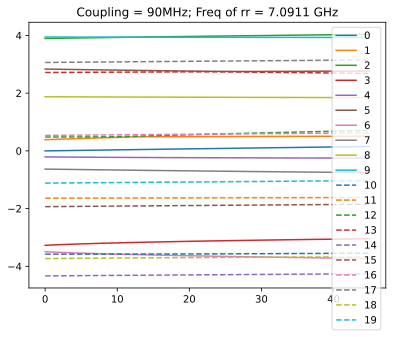

In [372]:
plt.figure()
for i in range(branch_num):
    br_e = [x%fr for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=fr/2:
            br_e[a] = x
        else:
            br_e[a] = x-fr
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [373]:
# de_opr = tensor(destroy(n_res),qeye(m))
# Nq = []
# Nr = []
# for k in range(branch_num):
#     nq = []
#     nr = []
#     for i,j in enumerate(indx_mat[k]):
#         C = S_rf[j]
#         exct_num = 0
#         for l in range(n_res):
#             for s in range(m):
#                 D = tensor(S_r[l],S_flx[s])
#                 exct_num = s*(abs(D.dag()*C))**2 + exct_num
#         nq.append(exct_num)
#         nr.append(abs(C.dag()*cr_opr*de_opr*C))
#     Nq.append(nq)
#     Nr.append(nr)

de_opr = tensor(destroy(n_res), qeye(m))
Nq = []
Nr = []

for k in range(branch_num):
    nq = []
    nr = []

    for i, j in enumerate(indx_mat[k]):
        C = S_rf[j]
        exct_num = 0

        for l in range(n_res):
            for s in range(m):
                D = tensor(S_r[l], S_flx[s])

                # compute |<D|C>|^2
                overlap = D.overlap(C)
                exct_num += s * np.abs(overlap)**2

        nq.append(exct_num)

        # number operator expectation value
        #nr.append(np.abs((C.dag() * cr_opr * de_opr * C).full()[0, 0]))
        nr.append(expect((cr_opr * de_opr), C))

    Nq.append(nq)
    Nr.append(nr)


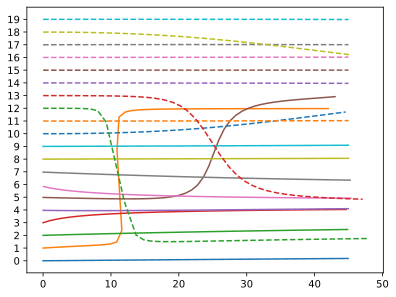

In [380]:
plt.figure()
for k in range(branch_num):
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    elif 10<=k<20:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls=':')
plt.yscale("linear")
x = np.arange(0,20)
plt.yticks(x)
# plt.legend()
plt.show()
        #plt.plot(Nr_11,Nt_11)
#plt.plot(Nr_12,Nt_12)

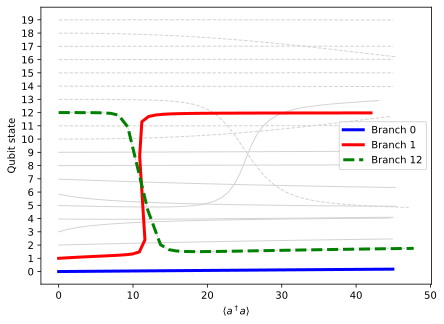

In [381]:
plt.figure(figsize=(7,5))

# Plot all branches faded
for k in range(branch_num):
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    plt.plot(Nr[k], Nq[k], ls=ls, color='lightgray', lw=1)

# Highlight selected branches
highlight = {
    0: ('blue', 3),
    1: ('red', 3),
    12: ('green', 3),
}

for k, (color, lw) in highlight.items():
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    plt.plot(Nr[k], Nq[k],
             color=color,
             lw=lw,
             ls=ls,
             label=f'Branch {k}')

plt.yticks(np.arange(20))
plt.xlabel(r'$\langle a^\dagger a \rangle$')
plt.ylabel('Qubit state')
plt.legend()
plt.show()

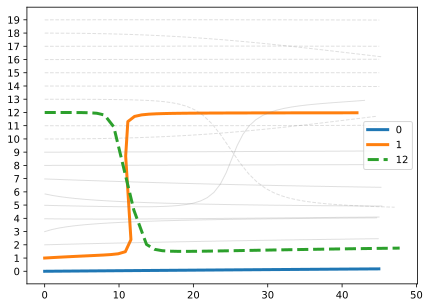

In [376]:
highlight = [0, 1, 12]

plt.figure(figsize=(7,5))

for k in range(branch_num):
    if k < 10:
        ls = '-'
    elif k < 20:
        ls = '--'
    else:
        ls = ':'

    if k in highlight:
        plt.plot(Nr[k], Nq[k], ls=ls, lw=3, label=f'{k}')
    else:
        plt.plot(Nr[k], Nq[k], ls=ls, color='gray', alpha=0.25, lw=1)

plt.yticks(np.arange(20))
plt.legend()
plt.show()

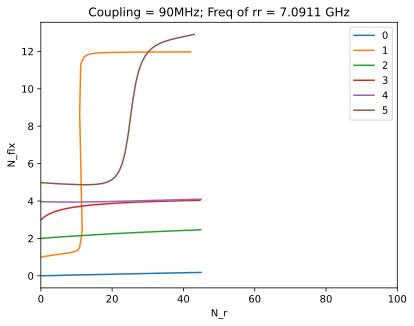

In [377]:
plt.figure()
for k in [0,1,2,3,4,5]: # 7,11,13,14,25,28
    if k<10:
        plt.plot(Nr[k],Nq[k],label = f"{k}")
    else:
        plt.plot(Nr[k],Nq[k],label = f"{k}",ls='--')
plt.legend()
plt.xlabel('N_r')
plt.ylabel('N_flx')
plt.xlim(0,100)
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")
plt.legend()

Text(0.5, 1.0, 'Coupling = 90MHz; Freq of rr = 7.0911 GHz')

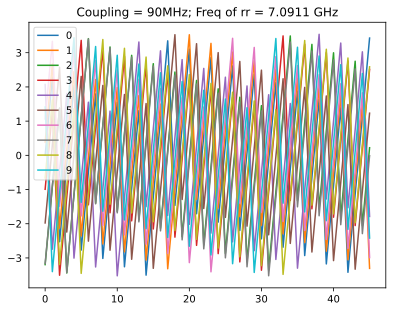

In [378]:
plt.figure()
for i in range(10):
    br_e = [x%7.0911 for x in branch[i]]
    #br_e = [x if x<=3.75 else 3.75-x for x in br_e]
    for a,x in enumerate(br_e):
        if x<=7.0911/2:
            br_e[a] = x
        else:
            br_e[a] = x-7.0911
    #br_e = [x if x<=3.75 else x-7.5 for x in br_e]
    if i<10:
        plt.plot(br_e, label = f'{i}')
    elif 10<=i<20:
        plt.plot(br_e, label = f'{i}',ls='--')
    else:
        plt.plot(br_e, label = f'{i}',ls=':')
#plt.xlim(0,170)
#plt.ylim(-3.74,3.74)
plt.legend()
plt.title("Coupling = 90MHz; Freq of rr = 7.0911 GHz")

In [379]:
E_flx

array([0.00000000e+00, 3.88547780e-01, 3.90223828e+00, 6.11015607e+00,
       9.18289193e+00, 1.22289655e+01, 1.52801980e+01, 1.81355516e+01,
       2.06373502e+01, 2.27071150e+01, 2.45538654e+01, 2.64969793e+01,
       2.86212932e+01, 3.08614065e+01, 3.31864080e+01, 3.55902560e+01,
       3.80634895e+01, 4.05949962e+01, 4.31749405e+01, 4.57937485e+01,
       4.84414606e+01, 5.11076442e+01, 5.37812006e+01, 5.64501257e+01,
       5.91013498e+01, 6.17207366e+01, 6.42934759e+01, 6.68053244e+01,
       6.92452853e+01, 7.16098706e+01, 7.39073437e+01, 7.61581589e+01,
       7.83889893e+01, 8.06235971e+01, 8.28772741e+01, 8.51572795e+01,
       8.74660963e+01, 8.98040730e+01, 9.21706416e+01, 9.45647342e+01,
       9.69849504e+01, 9.94296647e+01, 1.01897094e+02, 1.04385331e+02,
       1.06892359e+02, 1.09416054e+02, 1.11954182e+02, 1.14504394e+02,
       1.17064214e+02, 1.19631028e+02, 1.22202076e+02, 1.24774444e+02,
       1.27345054e+02, 1.29910677e+02, 1.32467947e+02, 1.35013411e+02,
      